# YOLO26n 통합 드론 탐지 모델 학습 기록

이 노트북은 2026-09-18에 두 Kaggle 드론 데이터셋을 정제·통합하고 YOLO26n을 실제로 학습한 방법과 결과를 기록한다. 학습은 Ultralytics CLI로 수행했으며, 아래 코드 셀은 저장된 데이터 메타데이터, 학습 로그, 평가 산출물과 최종 모델을 다시 읽어 검증한다.

- `muki2003/yolo-drone-detection-dataset`
- `monkeyboy999/drones-dataset-yolo`
- 최종 모델: `codes/server/drone-detection-yolo26n.pt`
- 학습 산출물: `codes/server/runs/drone-yolo26n-combined/`

## 1. 데이터 준비와 분할 방식

모든 이미지는 SHA-256으로 비교했다. 첫 번째 데이터셋의 중복 20장과 두 번째 데이터셋의 중복 12장을 제외했으며, 분할을 가로지르는 중복은 평가 세트의 사본을 유지했다. 두 출처 사이의 동일 이미지는 없었다.

첫 번째 데이터셋의 원래 검증 이미지는 테스트로 보존했다. 중복 제거된 원래 학습 풀의 10%를 시드 42로 검증에 배정했다. 두 번째 데이터셋은 정제된 원본 train/val/test 분할을 유지했다. 따라서 두 출처가 모두 독립 테스트에 포함되며 테스트 이미지는 학습이나 모델 선택에 사용되지 않는다.

빈 라벨 929개는 드론이 없는 배경 이미지이며 정상적인 음성 샘플로 유지했다. 모든 라벨은 `class x_center y_center width height`의 다섯 필드, 클래스 `0`, 정규화 좌표 `0..1` 조건을 검사했다.

In [1]:
from pathlib import Path
import csv
import hashlib
import json
import shlex

import torch
import ultralytics
from IPython.display import Image, Markdown, display
from ultralytics import YOLO

repo_root = Path.cwd().resolve()
dataset_dir = repo_root / 'datasets' / 'combined-drone'
data_yaml = dataset_dir / 'data.yaml'
model_path = repo_root / 'codes' / 'server' / 'drone-detection-yolo26n.pt'
train_run = repo_root / 'codes' / 'server' / 'runs' / 'drone-yolo26n-combined'
gpu_test_run = repo_root / 'codes' / 'server' / 'runs' / 'drone-yolo26n-combined-test-gpu'

environment = {
    'python': '.'.join(map(str, __import__('sys').version_info[:3])),
    'torch': torch.__version__,
    'ultralytics': ultralytics.__version__,
    'dataset_yaml': str(data_yaml.relative_to(repo_root)),
    'model': str(model_path.relative_to(repo_root)),
}
environment

{'python': '3.12.13',
 'torch': '2.9.1+cu130',
 'ultralytics': '8.4.155',
 'dataset_yaml': 'datasets/combined-drone/data.yaml',
 'model': 'codes/server/drone-detection-yolo26n.pt'}

In [2]:
metadata = json.loads((dataset_dir / 'metadata.json').read_text(encoding='utf-8'))
rows = ['| split | images | boxes | empty labels | by source |', '| --- | ---: | ---: | ---: | --- |']
for split, values in metadata['splits'].items():
    sources = ', '.join(f'{name}: {count}' for name, count in values['by_source'].items())
    rows.append(f"| {split} | {values['images']} | {values['boxes']} | {values['empty_labels']} | {sources} |")
display(Markdown('\n'.join(rows)))
metadata['totals']

| split | images | boxes | empty labels | by source |
| --- | ---: | ---: | ---: | --- |
| train | 7994 | 8255 | 650 | muki2003: 897, monkeyboy999: 7097 |
| val | 1625 | 1664 | 140 | muki2003: 100, monkeyboy999: 1525 |
| test | 1866 | 1909 | 139 | muki2003: 342, monkeyboy999: 1524 |

{'images': 11485, 'boxes': 11828, 'empty_labels': 929}

In [3]:
def manifest_images(name):
    manifest = dataset_dir / f'{name}.txt'
    result = []
    for line in manifest.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        path = Path(line)
        if line.startswith('./'):
            path = (manifest.parent / line).resolve()
        result.append(path)
    return result

def label_path(image_path):
    parts = list(image_path.parts)
    index = len(parts) - 1 - parts[::-1].index('images')
    parts[index] = 'labels'
    return Path(*parts).with_suffix('.txt')

split_images = {name: manifest_images(name) for name in ('train', 'val', 'test')}
all_paths = [path for paths in split_images.values() for path in paths]
invalid_rows = 0
missing_labels = 0
box_count = 0

for image_path in all_paths:
    target = label_path(image_path)
    if not target.is_file():
        missing_labels += 1
        continue
    for row in target.read_text(encoding='utf-8').splitlines():
        if not row.strip():
            continue
        fields = row.split()
        valid = len(fields) == 5 and fields[0] == '0'
        if valid:
            coords = [float(value) for value in fields[1:]]
            valid = all(0 <= value <= 1 for value in coords) and coords[2] > 0 and coords[3] > 0
        invalid_rows += int(not valid)
        box_count += int(valid)

validation = {
    'split_sizes': {name: len(paths) for name, paths in split_images.items()},
    'unique_paths': len(set(all_paths)),
    'split_overlap': sum(
        len(set(split_images[a]) & set(split_images[b]))
        for a, b in (('train', 'val'), ('train', 'test'), ('val', 'test'))
    ),
    'missing_labels': missing_labels,
    'valid_boxes': box_count,
    'invalid_label_rows': invalid_rows,
}
validation

{'split_sizes': {'train': 7994, 'val': 1625, 'test': 1866},
 'unique_paths': 11485,
 'split_overlap': 0,
 'missing_labels': 0,
 'valid_boxes': 11828,
 'invalid_label_rows': 0}

## 2. 실제 학습 설정

COCO 사전 학습 `yolo26n.pt`에서 시작해 단일 클래스 드론 탐지기로 파인튜닝했다. 입력 크기 640, batch 32, 최대 50 epoch, patience 10을 사용했다. 시드는 42로 고정하고 deterministic 모드를 켰다. Ultralytics `optimizer=auto`, AMP, 기본 색상·좌우 반전·mosaic 증강을 사용했으며 마지막 10 epoch에는 기본 `close_mosaic=10` 동작으로 mosaic을 중단했다.

학습 장치는 NVIDIA GeForce RTX 5060 Ti 16GB였고 Ultralytics 8.4.155, PyTorch 2.9.1+cu130 환경에서 실행했다.

In [4]:
train_config = {
    'model': 'yolo26n.pt',
    'data': str(data_yaml),
    'epochs': 50,
    'imgsz': 640,
    'batch': 32,
    'device': 0,
    'workers': 8,
    'seed': 42,
    'deterministic': True,
    'patience': 10,
    'cache': False,
    'plots': True,
    'project': str(repo_root / 'codes' / 'server' / 'runs'),
    'name': 'drone-yolo26n-combined',
    'exist_ok': True,
}

actual_command = [
    str(repo_root / 'codes' / 'server' / '.venv' / 'bin' / 'yolo'),
    'detect', 'train',
] + [f'{key}={value}' for key, value in train_config.items()]
print(shlex.join(actual_command))

./codes/server/.venv/bin/yolo detect train model=yolo26n.pt data=./datasets/combined-drone/data.yaml epochs=50 imgsz=640 batch=32 device=0 workers=8 seed=42 deterministic=True patience=10 cache=False plots=True project=./codes/server/runs name=drone-yolo26n-combined exist_ok=True


In [5]:
# 같은 학습을 Python API로 재현할 때 True로 바꾼다.
# 현재는 완료된 run과 best.pt를 보존하기 위해 재학습하지 않는다.
RUN_TRAINING = False

if RUN_TRAINING:
    reproduced_model = YOLO(train_config.pop('model'))
    reproduced_model.train(**train_config)
else:
    print('실제 50 epoch 학습 완료: codes/server/runs/drone-yolo26n-combined')

실제 50 epoch 학습 완료: codes/server/runs/drone-yolo26n-combined


## 3. 학습 결과와 모델 선택

각 epoch의 검증 mAP50-95를 모델 선택 기준으로 사용했다. 총 학습 시간은 약 27.5분이며 50 epoch가 최고 mAP50-95를 기록했다. 아래 셀은 저장된 `results.csv`를 직접 읽어 최고 epoch를 다시 계산한다.

In [6]:
with (train_run / 'results.csv').open(newline='', encoding='utf-8') as file:
    rows = list(csv.DictReader(file))

best_row = max(rows, key=lambda row: float(row['metrics/mAP50-95(B)']))
best_summary = {
    'best_epoch': int(best_row['epoch']),
    'training_seconds': round(float(best_row['time']), 1),
    'precision': round(float(best_row['metrics/precision(B)']), 5),
    'recall': round(float(best_row['metrics/recall(B)']), 5),
    'mAP50': round(float(best_row['metrics/mAP50(B)']), 5),
    'mAP50-95': round(float(best_row['metrics/mAP50-95(B)']), 5),
}
best_summary

{'best_epoch': 50,
 'training_seconds': 1647.7,
 'precision': 0.97019,
 'recall': 0.94952,
 'mAP50': 0.97315,
 'mAP50-95': 0.62548}

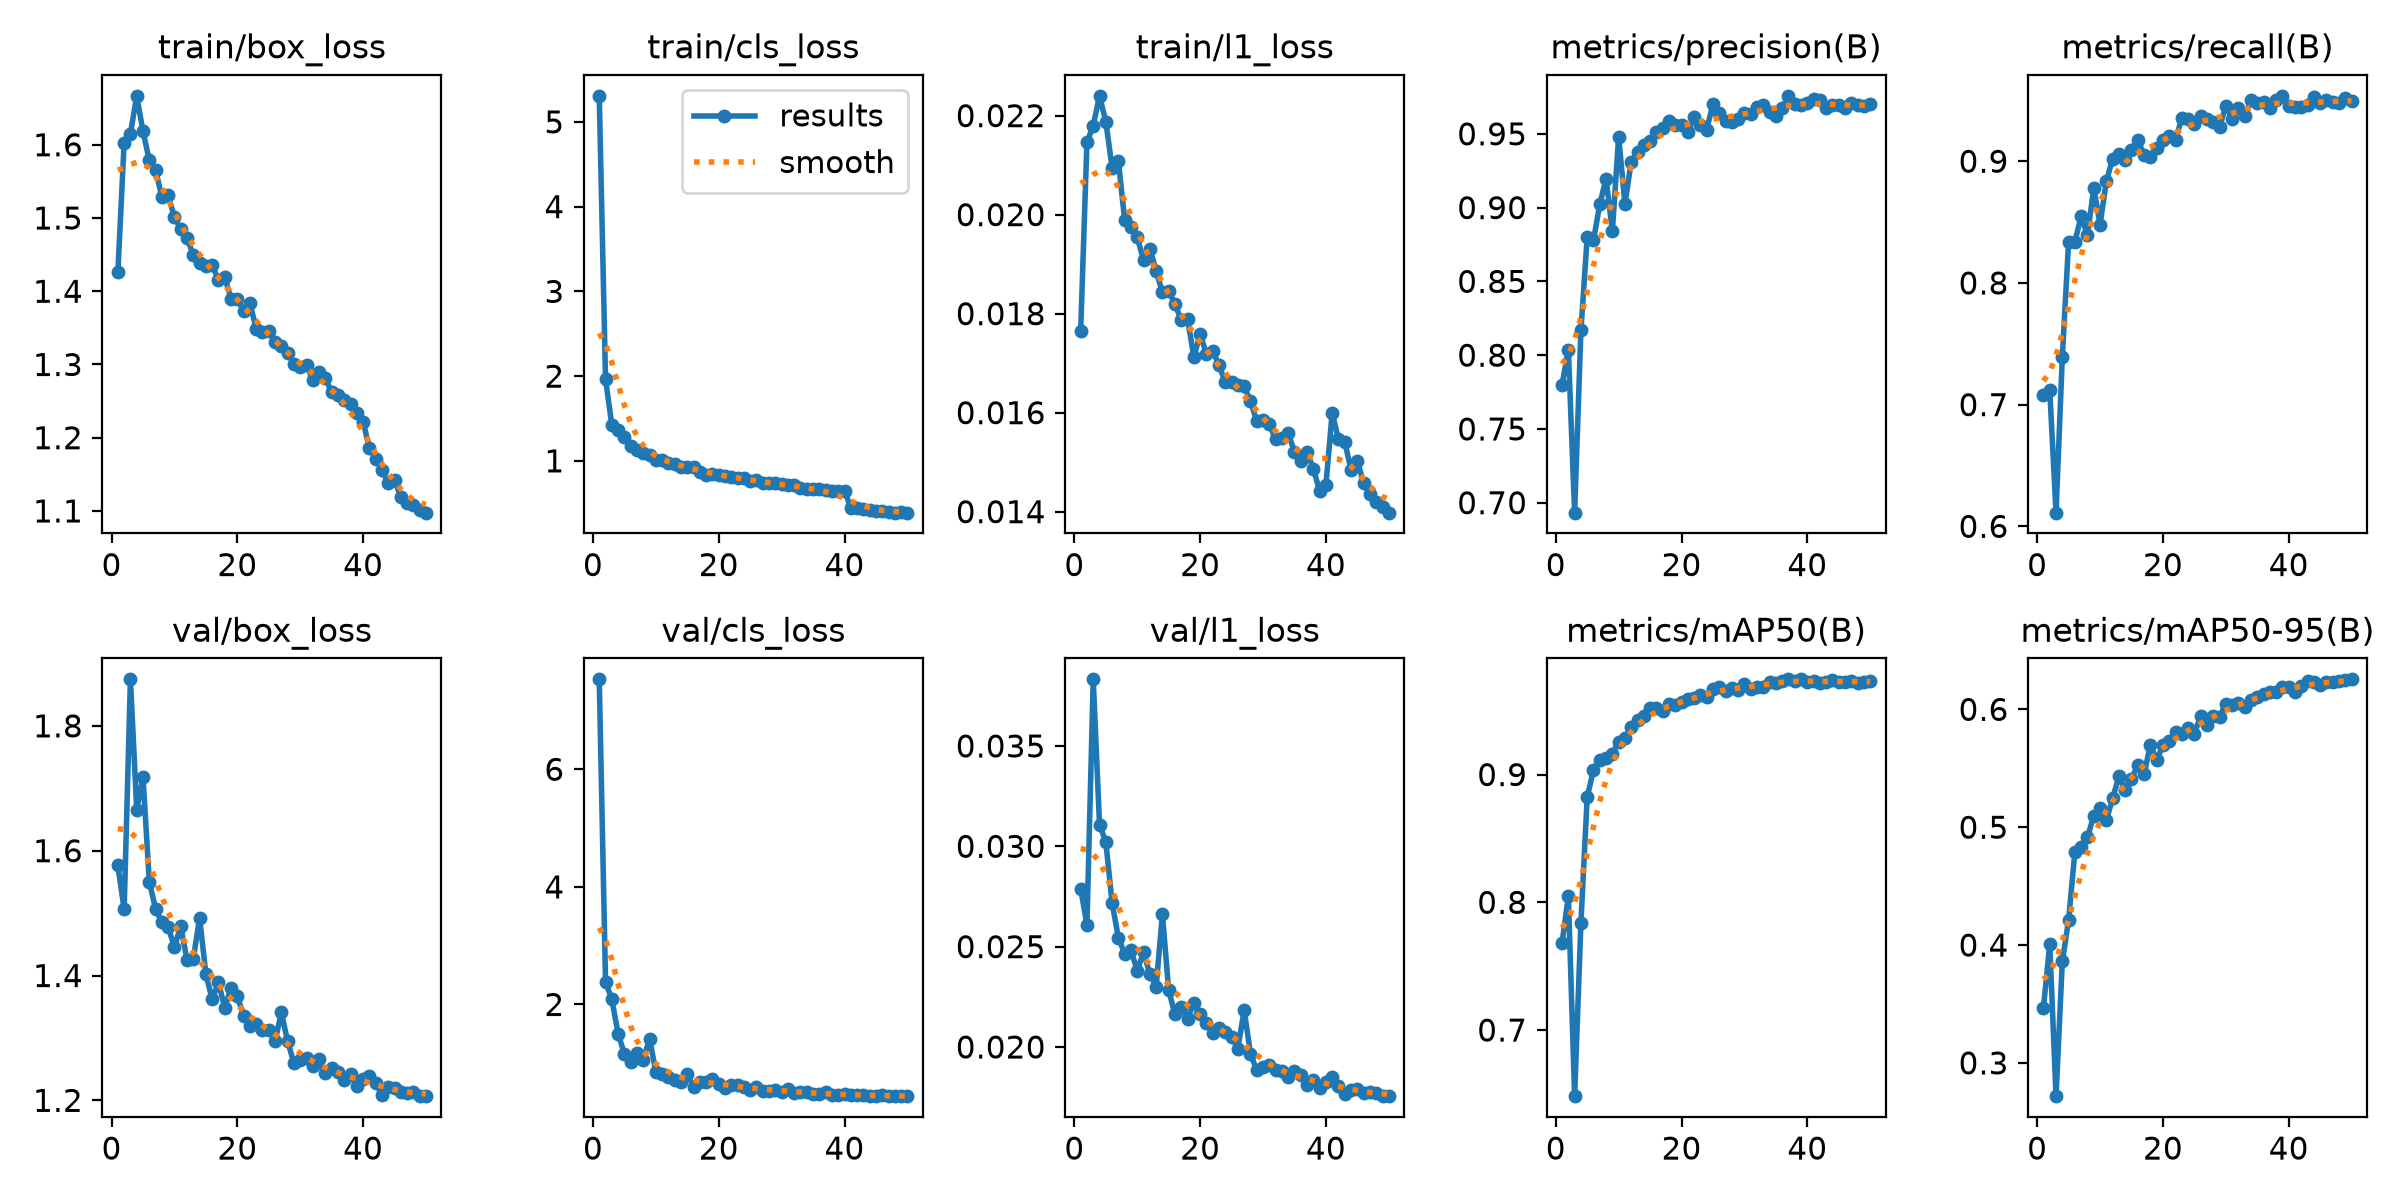

In [7]:
display(Image(filename=str(train_run / 'results.png')))

## 4. 독립 테스트

모델 선택에 사용하지 않은 1,866장으로 최종 평가했다. 정확도 재현성을 확인하기 위해 전체 테스트를 GPU와 CPU에서 각각 수행했고, 두 데이터 출처별 GPU 결과도 따로 측정했다. CPU 결과는 실제 서비스 추론 조건의 기준값이다.

In [8]:
training_summary = json.loads((dataset_dir / 'training_summary.json').read_text(encoding='utf-8'))
rows = [
    '| evaluation | images | instances | precision | recall | mAP50 | mAP50-95 | inference ms/image |',
    '| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |',
]
for name, values in training_summary['test'].items():
    rows.append(
        f"| {name} | {values['images']} | {values['instances']} | {values['precision']:.3f} | "
        f"{values['recall']:.3f} | {values['map50']:.3f} | {values['map50_95']:.3f} | "
        f"{values['inference_ms_per_image']:.1f} |"
    )
display(Markdown('\n'.join(rows)))

| evaluation | images | instances | precision | recall | mAP50 | mAP50-95 | inference ms/image |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| combined_gpu | 1866 | 1909 | 0.977 | 0.959 | 0.971 | 0.614 | 1.6 |
| combined_cpu | 1866 | 1909 | 0.976 | 0.960 | 0.971 | 0.614 | 16.0 |
| muki2003_gpu | 342 | 363 | 0.977 | 0.948 | 0.962 | 0.645 | 1.3 |
| monkeyboy999_gpu | 1524 | 1546 | 0.976 | 0.962 | 0.972 | 0.607 | 1.7 |

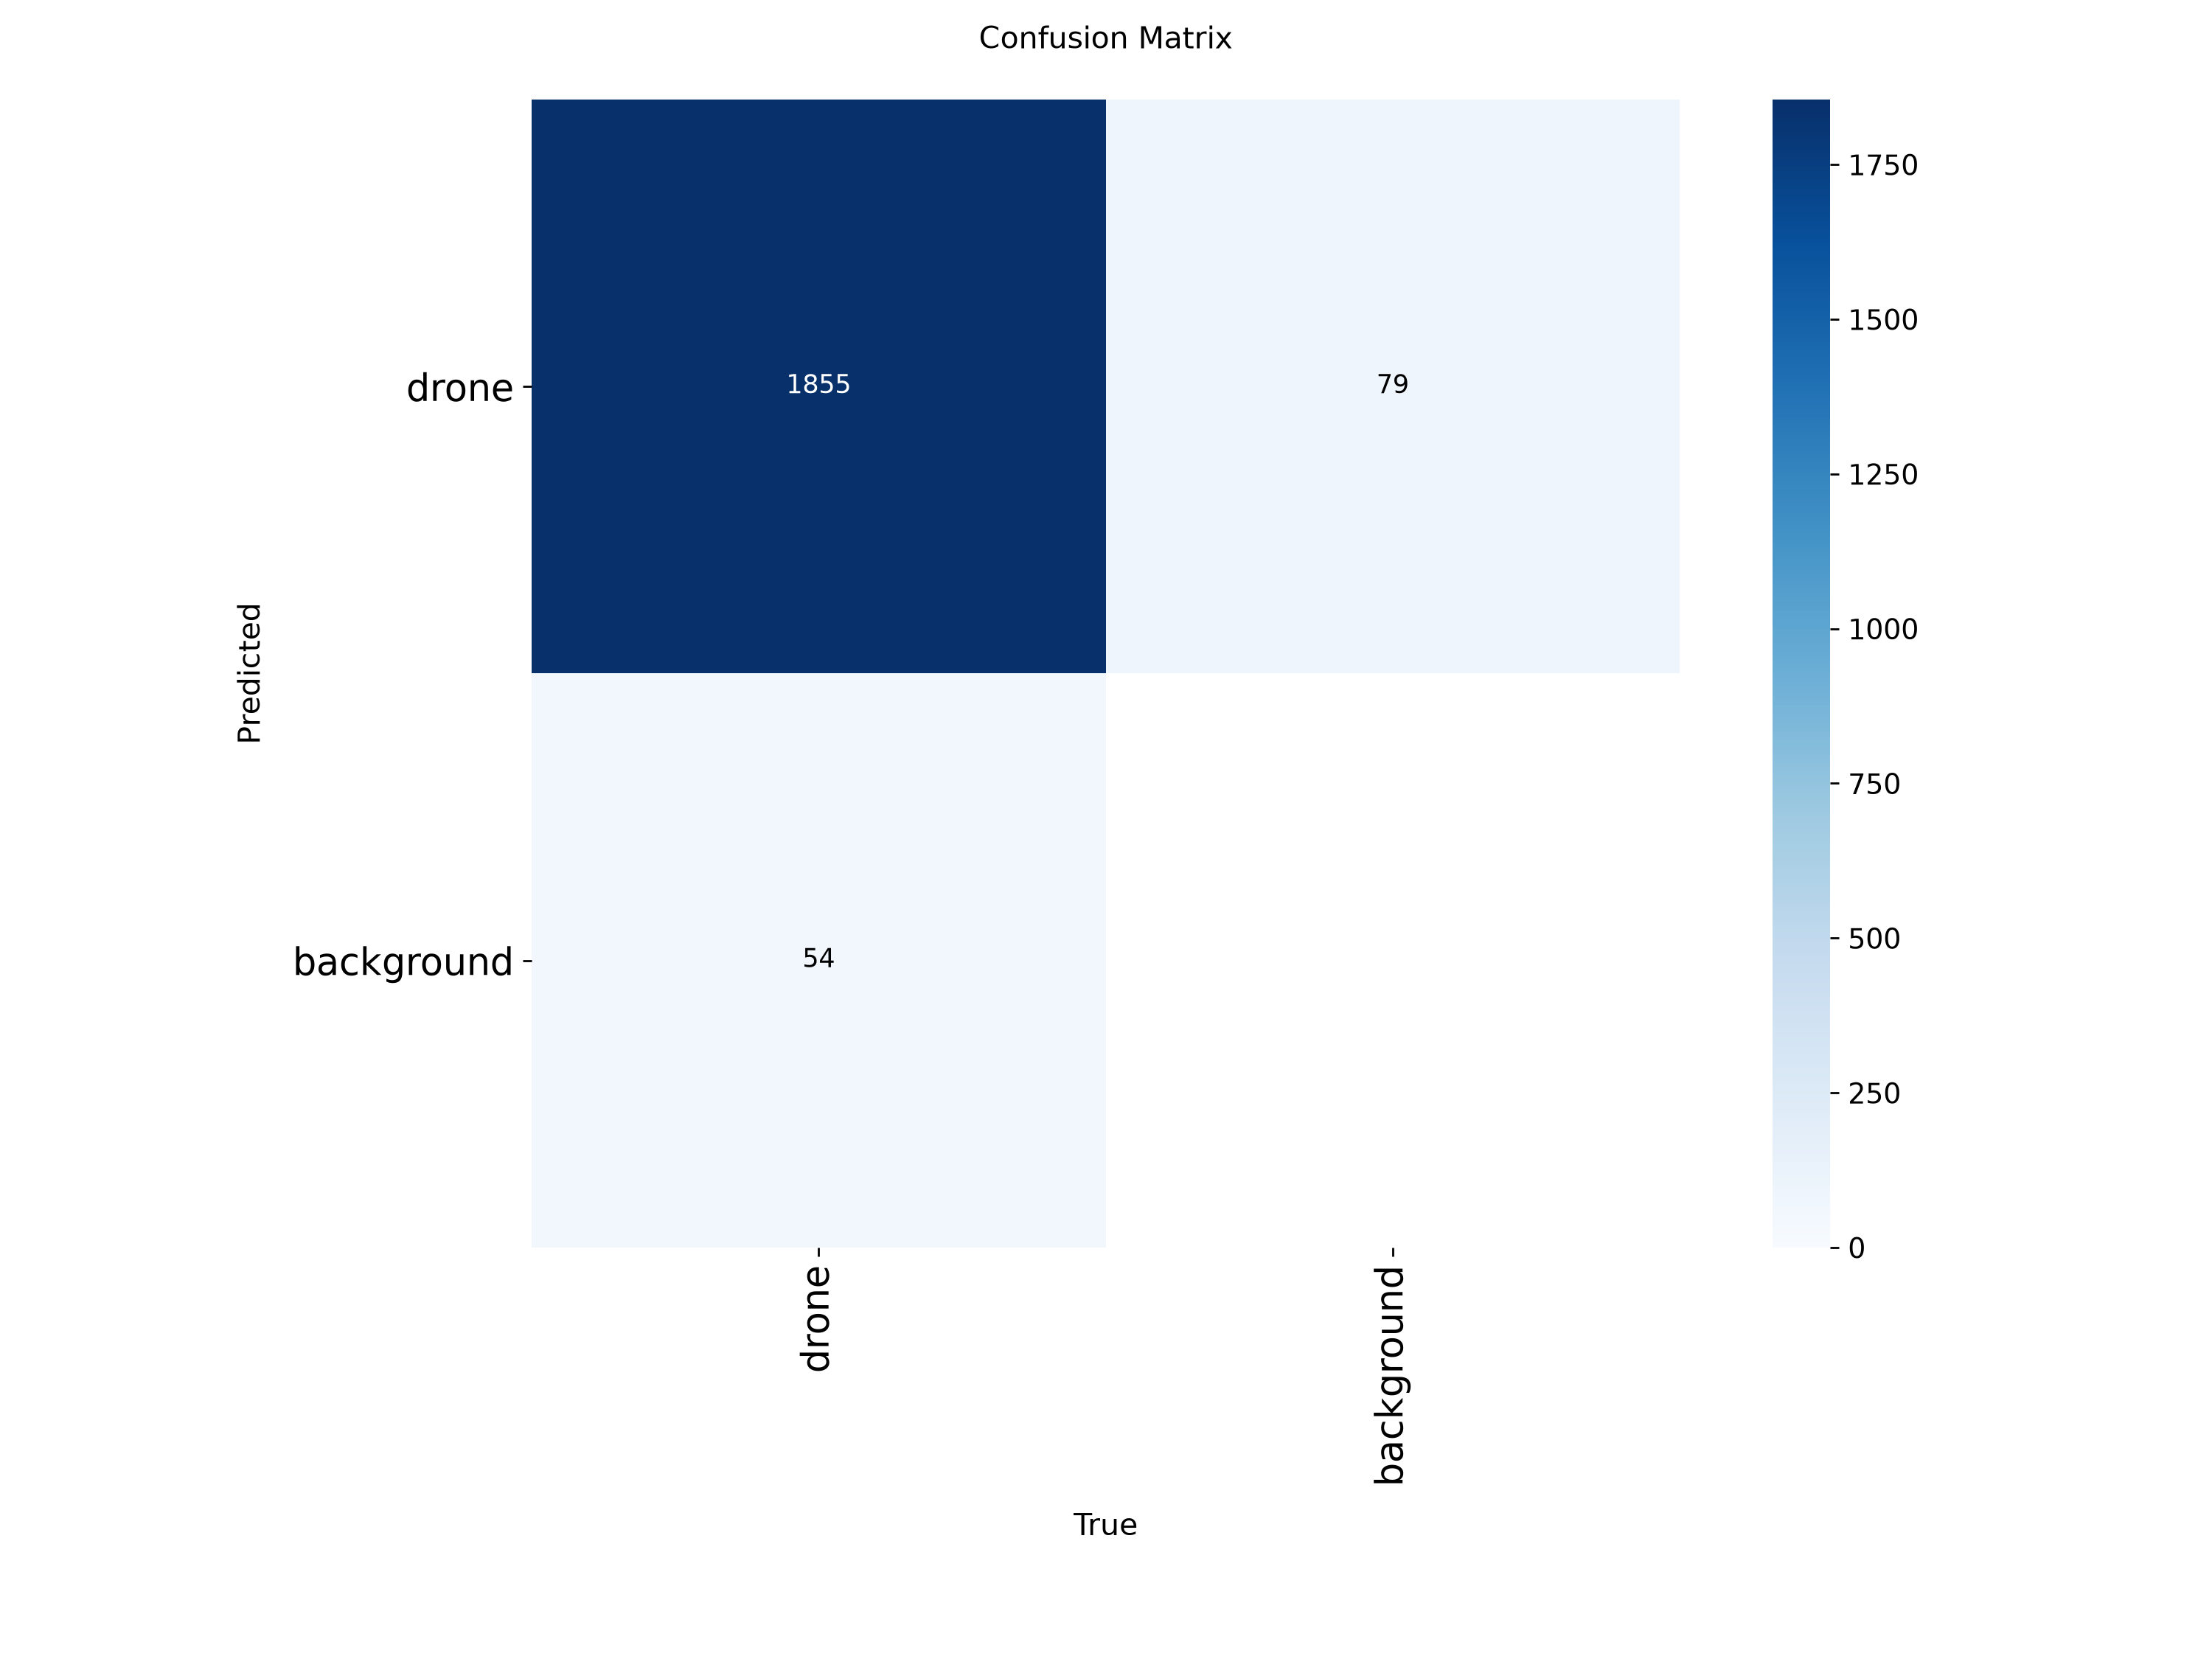

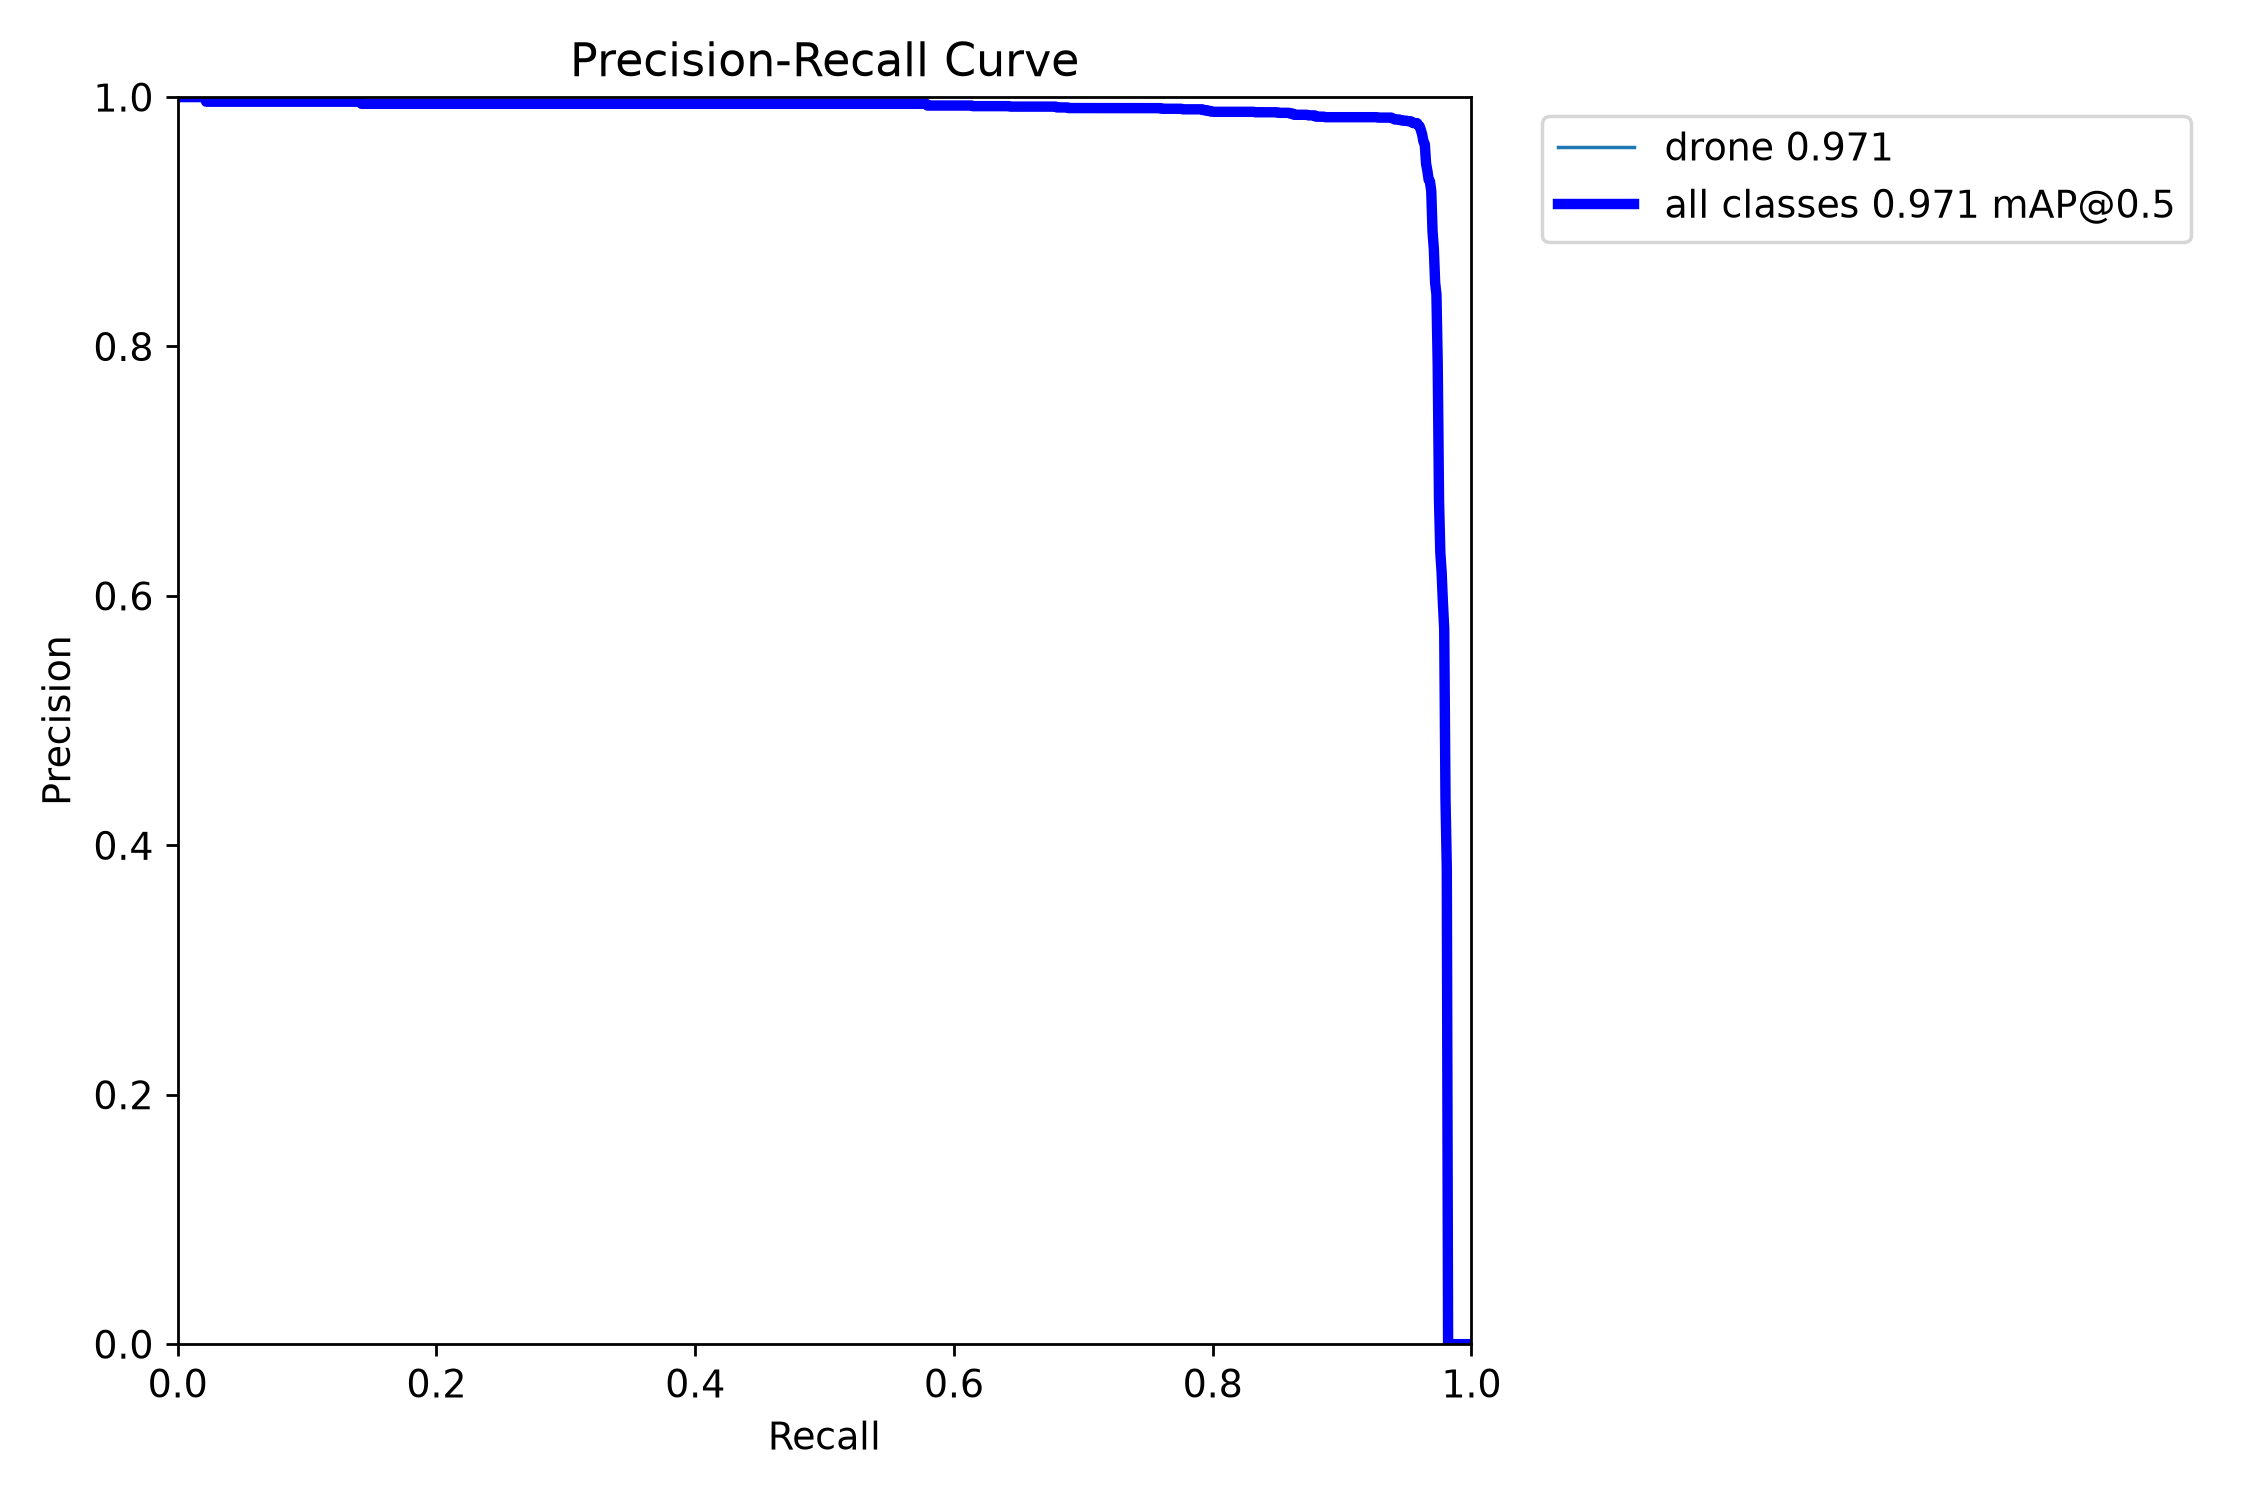

In [9]:
display(Image(filename=str(gpu_test_run / 'confusion_matrix.png')))
display(Image(filename=str(gpu_test_run / 'BoxPR_curve.png')))

출처별 mAP50-95는 첫 번째 데이터셋 0.645, 두 번째 데이터셋 0.607이다. 두 번째 데이터셋에는 배경 139장이 포함되고 촬영 조건과 해상도가 더 다양하므로 전체 테스트 결과는 두 출처 사이인 0.614가 되었다. 전체 GPU와 CPU의 mAP 결과는 반올림 기준으로 동일했다.

## 5. 최종 서비스 모델 검증

검증 mAP50-95가 가장 높은 `best.pt`를 `codes/server/drone-detection-yolo26n.pt`로 복사했다. 아래 셀은 체크섬을 확인하고 통합 테스트 이미지 하나를 CPU로 직접 추론한다.

In [10]:
model_sha256 = hashlib.sha256(model_path.read_bytes()).hexdigest()
model = YOLO(model_path)
sample_image = split_images['test'][0]
prediction = model.predict(source=sample_image, imgsz=640, device='cpu', verbose=False)[0]

verification = {
    'sha256': model_sha256,
    'classes': model.names,
    'sample': str(sample_image.relative_to(repo_root)),
    'detections': len(prediction.boxes),
    'top_confidence': round(float(prediction.boxes.conf.max()), 4) if len(prediction.boxes) else None,
}
verification

{'sha256': '9b0f104ef16662d471f99e3a394f8ff20bcac5ea80a8f7af0380b64bd3073702',
 'classes': {0: 'drone'},
 'sample': 'images/0001.jpg',
 'detections': 5,
 'top_confidence': 0.7851}

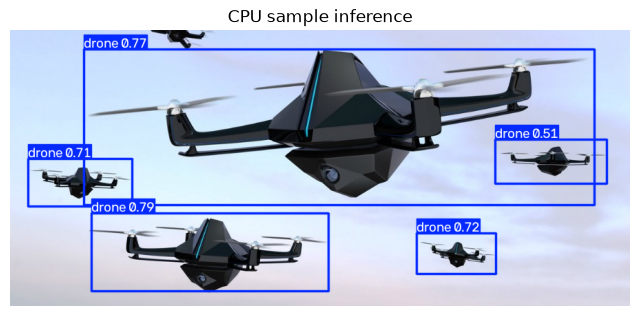

In [11]:
import matplotlib.pyplot as plt

annotated = prediction.plot()
plt.figure(figsize=(8, 8))
plt.imshow(annotated[..., ::-1])
plt.axis('off')
plt.title('CPU sample inference')
plt.show()

## 6. 산출물

- 서비스 가중치: `codes/server/drone-detection-yolo26n.pt`
- 학습 로그와 시각화: `codes/server/runs/drone-yolo26n-combined/`
- GPU 테스트 시각화: `codes/server/runs/drone-yolo26n-combined-test-gpu/`
- 통합 데이터 정의: `datasets/combined-drone/`
- 모델 SHA-256: `9b0f104ef16662d471f99e3a394f8ff20bcac5ea80a8f7af0380b64bd3073702`

## 7. 모바일 실시간 탐지와 배포 확장 계획

현재 노트북이 검증한 `drone-detection-yolo26n.pt`는 사진 탐지 API의 기준 모델이다. 다음 서비스 단계에서는 기존 학습 결과를 바꾸지 않고 배포 런타임과 입력 방식을 확장한다.

### 실시간 카메라 입력

- 클라이언트는 사진 탐지와 실시간 카메라 화면을 구분한다.
- 모바일 브라우저는 사용자 동작 이후 `getUserMedia()`로 후면 카메라를 우선 요청한다.
- 카메라 프레임은 브라우저에서 최대 640픽셀로 축소하고 JPEG 또는 WebP 바이너리로 변환한다.
- WebSocket `/api/v1/stream`은 프레임을 받아 탐지 좌표, 신뢰도, 추론 시간과 프레임 식별자를 반환한다.
- 클라이언트는 이전 응답을 받은 뒤 다음 프레임을 보내 백프레셔를 적용하고, 측정 지연에 따라 전송 간격을 조절한다.
- 카메라 영상과 전송 프레임은 서버에 저장하지 않는다.

### ONNX 배포 후보 검증

Render 무료 Web Service의 제한된 CPU와 메모리를 고려하여 PyTorch 가중치를 ONNX로 내보낸다. ONNX Runtime을 서비스에 적용하기 전에 현재 독립 테스트 1,866장에서 아래 항목을 같은 조건으로 비교한다.

| 비교 항목 | PyTorch 기준 | ONNX 측정 예정 |
| --- | ---: | ---: |
| Precision | 0.977 | - |
| Recall | 0.959 | - |
| mAP50 | 0.971 | - |
| mAP50-95 | 0.614 | - |
| CPU 추론 시간 | 16.0 ms/image | - |
| 최대 메모리 | 측정 예정 | - |
| 모델 크기 | 측정 예정 | - |

ONNX 결과가 준비되기 전에는 위 빈 값을 추정치로 채우지 않는다. 정확도 차이, 지연 시간과 메모리를 실제로 측정한 뒤 배포 런타임을 결정하고 이 노트북에 실행 코드와 결과를 추가한다.

### Render 배포 구조

- React/Vite 클라이언트: Render Static Site
- FastAPI HTTP 및 WebSocket 서버: Render Web Service
- 공개 통신: HTTPS와 WSS
- 상태 확인: `GET /health`
- 서버 실행: Render의 `PORT` 환경 변수 사용, 모델 워커 1개
- 무료 서버가 유휴 종료된 경우 클라이언트에 준비 중 상태를 표시

이 절은 구현 및 측정 계획을 기록한 문서 셀이며, 기존 50 epoch 학습과 테스트 결과가 다시 실행되었다는 의미는 아니다.
